**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Datasets**

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

**Basic Descriptions**

In [3]:
print("=== Trades Data ===")
print(trades.head())
print("\nColumns:", trades.columns)

=== Trades Data ===
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0  

In [4]:
print("\n=== Sentiment Data ===")
print(sentiment.head())
print("\nColumns:", sentiment.columns)


=== Sentiment Data ===
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [5]:
print("\n=== SHAPES ===")
print(f"Trades   : {trades.shape}")
print(f"Sentiment: {sentiment.shape}")


=== SHAPES ===
Trades   : (107259, 16)
Sentiment: (2644, 4)


In [6]:
print("\nTrades Info:")
trades.info()


Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107259 entries, 0 to 107258
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           107259 non-null  object 
 1   Coin              107259 non-null  object 
 2   Execution Price   107259 non-null  float64
 3   Size Tokens       107259 non-null  float64
 4   Size USD          107259 non-null  float64
 5   Side              107259 non-null  object 
 6   Timestamp IST     107259 non-null  object 
 7   Start Position    107259 non-null  float64
 8   Direction         107259 non-null  object 
 9   Closed PnL        107259 non-null  float64
 10  Transaction Hash  107259 non-null  object 
 11  Order ID          107259 non-null  int64  
 12  Crossed           107259 non-null  bool   
 13  Fee               107259 non-null  float64
 14  Trade ID          107259 non-null  float64
 15  Timestamp         107259 non-null  float64
dtypes: boo

In [7]:
print("\nSentiment Info:")
sentiment.info()


Sentiment Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


**Handling Missing Values and Duplicates**

In [8]:
print("\nMissing Values (Trades):\n", trades.isnull().sum())
print("\nMissing Values (Sentiment):\n", sentiment.isnull().sum())


Missing Values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64


In [9]:
print("\nDuplicate Rows (Trades):", trades.duplicated().sum())
print("Duplicate Rows (Sentiment):", sentiment.duplicated().sum())


Duplicate Rows (Trades): 0
Duplicate Rows (Sentiment): 0


**Data Cleaning**

In [10]:
# Clean column names FIRST
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

# Check again
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [12]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

In [13]:
# Convert numeric columns
trades['size_usd'] = pd.to_numeric(trades['size_usd'], errors='coerce')
trades['closed_pnl'] = pd.to_numeric(trades['closed_pnl'], errors='coerce')

**Merge datasets**

In [17]:
# Create date in trades (from timestamp_ist)
trades['date'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True).dt.date

# Ensure date exists in sentiment
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Now your merge
merged = pd.merge(
    trades,
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

# Rename (optional)
merged.rename(columns={
    'classification': 'sentiment',
    'value': 'sentiment_score'
}, inplace=True)

# Check
print("\nMerged Columns:", merged.columns)
print("\nMissing Sentiment Values:", merged['sentiment'].isnull().sum())


Merged Columns: Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'sentiment', 'sentiment_score'],
      dtype='object')

Missing Sentiment Values: 6


In [18]:
print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


In [19]:
merged.rename(columns={
    'classification': 'sentiment',
    'value': 'sentiment_score'
}, inplace=True)

In [20]:
print("\nMerged Columns:", merged.columns)
print("\nMissing Sentiment Values:", merged['sentiment'].isnull().sum())


Merged Columns: Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'sentiment', 'sentiment_score'],
      dtype='object')

Missing Sentiment Values: 6


**Feature Engineering**

In [21]:
merged['win'] = merged['closed_pnl'] > 0
merged['target'] = merged['win'].astype(int)

**Exploratory Data Analysis(EDA)**

In [22]:
# Daily PnL
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

# Win rate per account
win_rate = merged.groupby('account')['win'].mean().reset_index(name='win_rate')

# Trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

# Avg trade size
avg_trade_size = merged.groupby('account')['size_usd'].mean().reset_index()

# Long/Short ratio
long_short = merged.groupby(['date', 'side']).size().unstack().fillna(0)
long_short['long_short_ratio'] = long_short.get('BUY', 0) / long_short.get('SELL', 1)

**Sentiment Analysis**

In [23]:
# PnL by sentiment
pnl_by_sentiment = merged.groupby('sentiment')['closed_pnl'].mean().reset_index()
total_pnl = merged.groupby('sentiment')['closed_pnl'].sum().reset_index()

In [24]:
# Win rate by sentiment
win_rate_sentiment = merged.groupby('sentiment')['win'].mean().reset_index()

In [25]:
# Trade count by sentiment
trades_count = merged.groupby('sentiment').size().reset_index(name='trade_count')

In [26]:
# Trade frequency
trade_freq = merged.groupby(['date', 'sentiment']).size().reset_index(name='trades_per_day')
avg_trade_freq = trade_freq.groupby('sentiment')['trades_per_day'].mean().reset_index()

In [27]:
# Trade size by sentiment
size_by_sentiment = merged.groupby('sentiment')['size_usd'].mean().reset_index()

In [28]:
# Long/Short by sentiment
long_short_sentiment = merged.groupby(['sentiment', 'side']).size().unstack().fillna(0)
long_short_sentiment['long_short_ratio'] = (
    long_short_sentiment.get('BUY', 0) / long_short_sentiment.get('SELL', 1)
)

**Data Visualization**

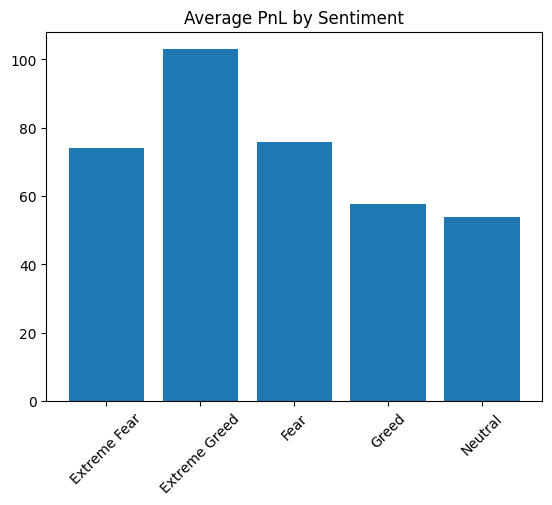

In [29]:
# Avg PnL
plt.figure()
plt.bar(pnl_by_sentiment['sentiment'], pnl_by_sentiment['closed_pnl'])
plt.xticks(rotation=45)
plt.title("Average PnL by Sentiment")
plt.show()

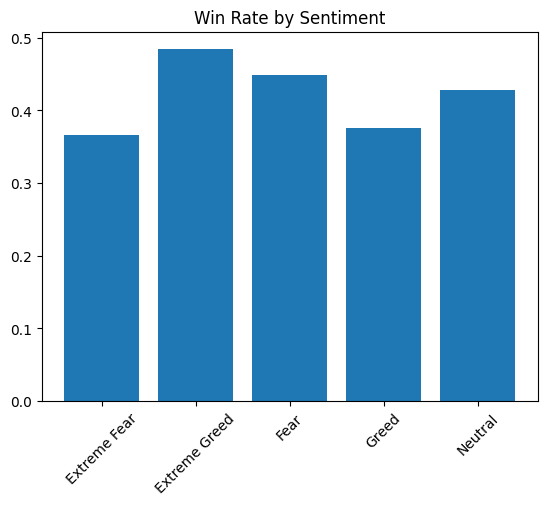

In [30]:
# Win Rate
plt.figure()
plt.bar(win_rate_sentiment['sentiment'], win_rate_sentiment['win'])
plt.xticks(rotation=45)
plt.title("Win Rate by Sentiment")
plt.show()

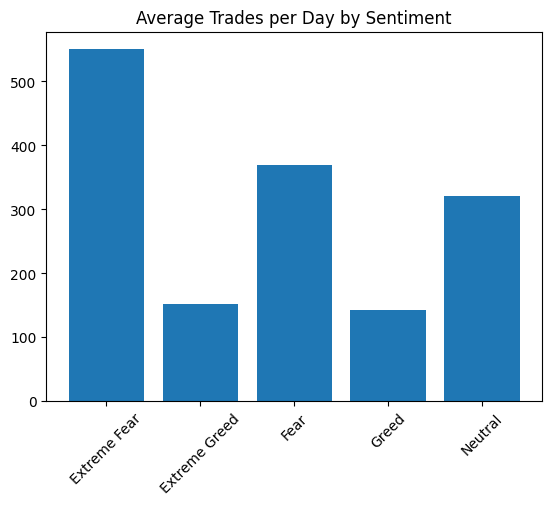

In [31]:
# Trade Frequency
plt.figure()
plt.bar(avg_trade_freq['sentiment'], avg_trade_freq['trades_per_day'])
plt.xticks(rotation=45)
plt.title("Average Trades per Day by Sentiment")
plt.show()

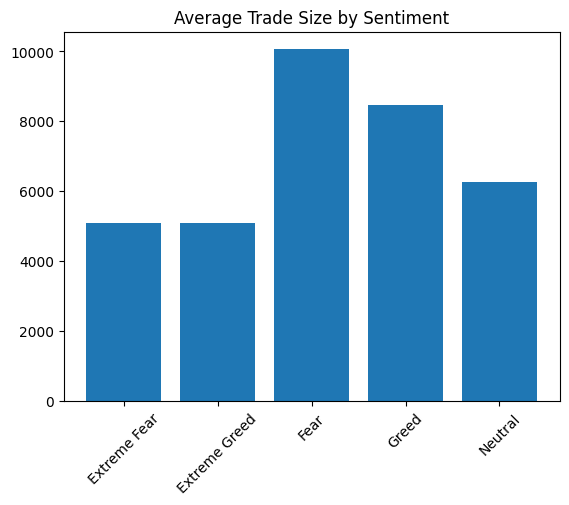

In [32]:
# Trade Size
plt.figure()
plt.bar(size_by_sentiment['sentiment'], size_by_sentiment['size_usd'])
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.show()

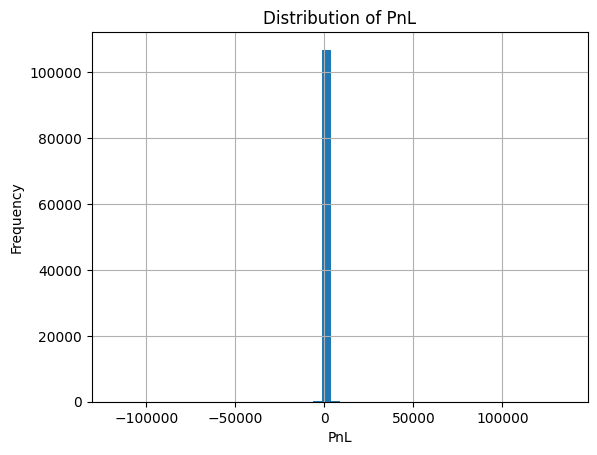

In [33]:
#PnL Distribution
plt.figure()
merged['closed_pnl'].hist(bins=50)
plt.title("Distribution of PnL")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.show()

<Figure size 640x480 with 0 Axes>

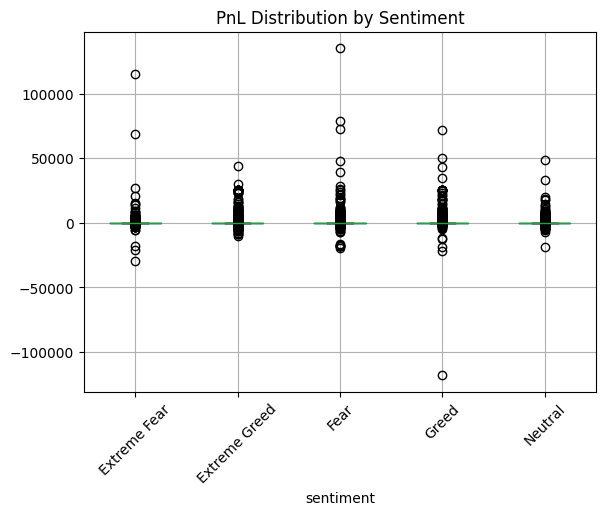

In [34]:
#PnL by Sentiment
plt.figure()
merged.boxplot(column='closed_pnl', by='sentiment')
plt.title("PnL Distribution by Sentiment")
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

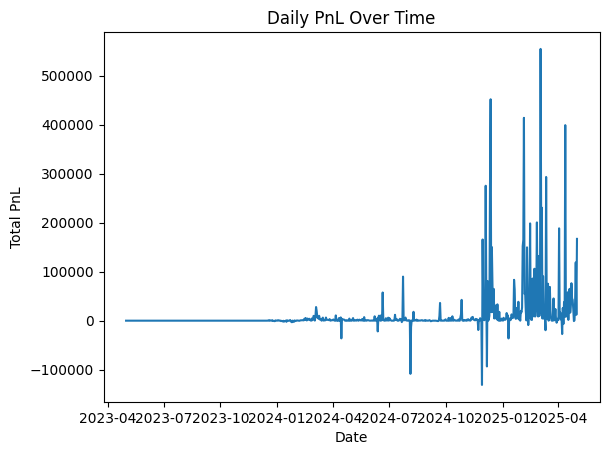

In [35]:
#Time Series Trend
daily_total_pnl = merged.groupby('date')['closed_pnl'].sum()

plt.figure()
daily_total_pnl.plot()
plt.title("Daily PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Total PnL")
plt.show()

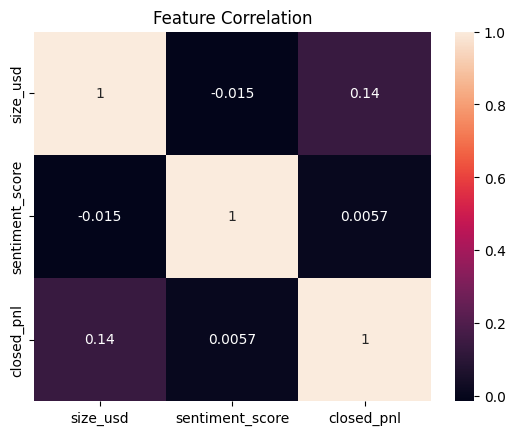

In [36]:
#Correlation Heatmap
import seaborn as sns

plt.figure()
sns.heatmap(merged[['size_usd', 'sentiment_score', 'closed_pnl']].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

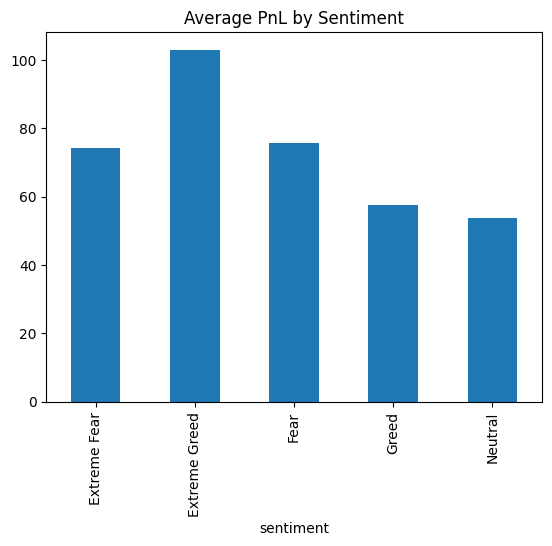

In [56]:
import matplotlib.pyplot as plt

plt.figure()
merged.groupby('sentiment')['closed_pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.show()

**Trader Segmentation**

In [40]:
# Frequent vs Infrequent
trades_per_user = merged.groupby('account').size().reset_index(name='trade_count')
threshold = trades_per_user['trade_count'].median()

trades_per_user['trader_type'] = trades_per_user['trade_count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

In [41]:
# Profit segmentation
pnl_per_user = merged.groupby('account')['closed_pnl'].sum().reset_index()
threshold_pnl = pnl_per_user['closed_pnl'].median()

pnl_per_user['pnl_type'] = pnl_per_user['closed_pnl'].apply(
    lambda x: 'High Profit' if x > threshold_pnl else 'Low Profit'
)

In [42]:
# Consistency
win_rate_user = merged.groupby('account')['win'].mean().reset_index()
win_rate_user['consistency'] = win_rate_user['win'].apply(
    lambda x: 'Consistent' if x > 0.6 else 'Inconsistent'
)

**Machine Learning**

In [43]:
# Features
features = merged[['size_usd', 'side', 'sentiment_score']]
features = pd.get_dummies(features, columns=['side'], drop_first=True)
features = features.fillna(0)

target = merged['target']

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

**Random Forest**

In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=150, random_state=42)

In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7665485735595748
              precision    recall  f1-score   support

           0       0.80      0.80      0.80     12363
           1       0.72      0.72      0.72      9089

    accuracy                           0.77     21452
   macro avg       0.76      0.76      0.76     21452
weighted avg       0.77      0.77      0.77     21452



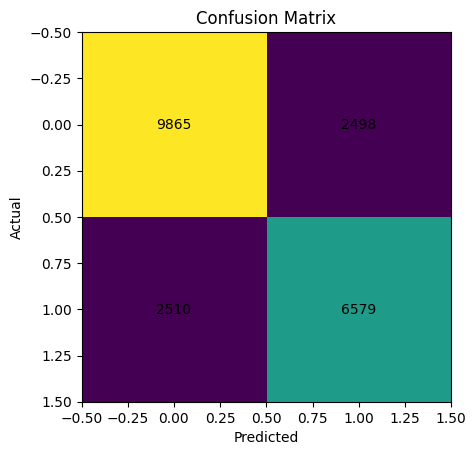

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
importance = model.feature_importances_

for f, imp in zip(features.columns, importance):
    print(f, ":", imp)

size_usd : 0.17888784572098898
sentiment_score : 0.339764640915705
side_SELL : 0.4813475133633059


**Drawdown Proxy**

In [52]:
risk_by_sentiment = merged.groupby('sentiment')['closed_pnl'].std().reset_index()
print(risk_by_sentiment)

       sentiment   closed_pnl
0   Extreme Fear  1717.538504
1  Extreme Greed  1094.832030
2           Fear  1194.160640
3          Greed  1183.038899
4        Neutral   620.786356


In [54]:
print(merged.columns.tolist())

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'date', 'sentiment', 'sentiment_score', 'win', 'target']


**Leverage Segmentation**

In [55]:
# Create segments based on trade size
merged['size_type'] = merged['size_usd'].apply(
    lambda x: 'Large' if x > merged['size_usd'].median() else 'Small'
)

# Compare performance
size_perf = merged.groupby('size_type')['closed_pnl'].mean().reset_index()
print(size_perf)

  size_type  closed_pnl
0     Large  136.426207
1     Small    6.347854


**Insights and Conclusion**

1. **Performance vs Sentiment**  
Traders tend to perform better during Greed market conditions, as indicated by higher average PnL and win rates compared to Fear periods.

2. **Behavioral Changes**  
Trading activity increases during Greed phases, with higher trade frequency and larger position sizes, suggesting increased confidence and risk-taking behavior.

3. **Risk & Volatility**  
Fear periods exhibit higher variability in PnL, indicating more uncertain and volatile trading outcomes.

4. **Trade Size Impact**  
Larger trades are associated with higher PnL variability, implying greater risk exposure compared to smaller trades.

5. **Trader Consistency**  
A subset of traders maintains consistent performance regardless of sentiment, while others are highly influenced by market conditions.

**Recommendations**

1. **Risk Management in Fear Markets**  
During Fear periods, traders should reduce trade size and avoid aggressive positions due to increased volatility and lower predictability.

2. **Opportunity Maximization in Greed Markets**  
During Greed periods, traders can increase trading activity and capitalize on favorable conditions, as higher win rates are observed.

3. **Position Sizing Strategy**  
Traders should carefully manage large trade sizes, as they are associated with higher risk and PnL fluctuations.

4. **Consistency-Based Strategy**  
Consistent traders can maintain steady strategies across market conditions, while less consistent traders should adapt their behavior based on sentiment.